In [1]:
!poetry install -q

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
import datetime
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# OpenMP 다중 로드 허용 및 스레드 경쟁 방지 환경 변수 (최상단 주입 필수)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# 1. 프로젝트 경로 설정 및 환경 변수 명시적 로드
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Docker 네트워크 외부(Host OS)에서 실행되는 Jupyter를 위한 DNS 해석 우회 처리
local_s3_endpoint = os.environ.get("LOCAL_S3_ENDPOINT", "")
if "localstack" in local_s3_endpoint:
    os.environ["LOCAL_S3_ENDPOINT"] = local_s3_endpoint.replace("localstack", "localhost")

In [3]:
# DataFrame 출력 생략 방지 옵션 설정
pd.set_option('display.max_columns', None)        # 숨김 없이 모든 컬럼 출력
pd.set_option('display.max_colwidth', None)       # 컬럼 안의 긴 텍스트(Dict/List) 전체 출력
pd.set_option('display.expand_frame_repr', False) # 가로 너비 초과 시 줄바꿈 방지
pd.set_option('display.max_rows', 50)             # 필요시 최대 출력 행 수 조정

In [4]:
# ==============================================================================
# [셀 0] 주피터 분석 환경 전용 MinIO 및 MLflow 환경 변수 세팅
# ==============================================================================
import os
import warnings
import logging
from dotenv import find_dotenv, load_dotenv
from mlflow.tracking import MlflowClient
from pandas.errors import PerformanceWarning
from src.model.tracker.mlflow_tracker import MLflowTracker

# 1. 루트 디렉터리의 .env 파일 자동 탐색 및 로드
load_dotenv(find_dotenv())

# 2. MinIO S3 및 AWS 자격 증명 환경 변수 세팅
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID", "minioadmin")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin")
os.environ["AWS_DEFAULT_REGION"] = os.getenv("AWS_DEFAULT_REGION", "us-east-1")
os.environ["LOCAL_S3_ENDPOINT"] = os.getenv("MLFLOW_S3_ENDPOINT_URL", "http://localhost:9000")

# 3. MLflow Tracking & S3 아티팩트 스토어 연동 설정
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_TRACKING_URI
os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("MLFLOW_S3_ENDPOINT_URL", "http://localhost:9000")
os.environ["MLFLOW_S3_IGNORE_TLS"] = "true"
# MLflow 공식 표준 출력 URL 링크 차단 환경변수 (소프트웨어 공식 플래그)
os.environ["MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT"] = "true"

# 4. 경고 필터링
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# MLFlow 활성화
EXPERIMENT_NAME: str = "Single_Model_FineTuning"
tracker = MLflowTracker(experiment_name=EXPERIMENT_NAME)

/Users/junsu/code/Project/AssetMind/apps/data-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🎯 [MLflow Tracker Active] Experiment: 'Single_Model_FineTuning' (ID: 1)


In [8]:
# ==============================================================================
# [셀 1] 완성형 챔피언 데이터셋(80:20) 로드 및 Walk-Forward CV 시계열 분할 무결성 감사
# ==============================================================================
import pandas as pd
from src.model.dataset.loader import ChampionDatasetLoader
from src.model.dataset.walk_forward_splitter import WalkForwardSplitter

# ------------------------------------------------------------------------------
# Step 1. get_best_dataset.ipynb에서 확정된 champion_dataset.pkl 로드 및 검증
# ------------------------------------------------------------------------------
X_train, y_train, X_test, y_test, X_inference = ChampionDatasetLoader.load_champion_dataset("champion_dataset.pkl")

# ------------------------------------------------------------------------------
# Step 2. 상위 80:20 Hold-out 파티션 통계 및 무결성 감사 대시보드 사출
# ------------------------------------------------------------------------------
partition_summary_df = ChampionDatasetLoader.create_partition_summary(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    X_inference=X_inference
)
display(partition_summary_df)

# ------------------------------------------------------------------------------
# Step 3. Train(80%) 내부 동적 Walk-Forward CV 분할 구간 정밀 감사표 사출
# ------------------------------------------------------------------------------
walk_forward_splitter = WalkForwardSplitter(n_splits=5, forecast_horizon=20, min_train_ratio=0.5)
walk_forward_audit_df = walk_forward_splitter.summarize(X=X_train, y=y_train)

print("\n" + "=" * 122)
print(f" 🔬 [Expanding-Window Walk-Forward CV Audit Dashboard] Total Folds: {len(walk_forward_audit_df)} Folds (Dynamic Sized)")
print("=" * 122)
display(walk_forward_audit_df)

 🚀 [Champion Dataset Ingestion] 'champion_dataset.pkl' 로드 완료 (1.95 ms | 크기: 931.24 KB)
 📌 Model-Ready Feature Dimension: 23개 정예 피처 선별 완비


,"X Shape (행, 피처)",y Shape (타겟),시계열 시작일,시계열 종료일,타겟 평균 (Mean),타겟 표준편차 (Std),타겟 범위 (Min ~ Max)
파티션 (Partition),,,,,,,
Train Set (개발/CV 튜닝용 80%),"(1987, 23)","(1987,)",2016-01-01,2021-06-28,-0.0021,0.6257,"[-1.6796, 1.5334]"
Test Set (최종 실전평가용 20%),"(497, 23)","(497,)",2021-07-19,2022-12-11,-0.1259,0.6526,"[-1.4150, 1.1448]"
Inference Set (실시간 추론 전용 T+20),"(20, 23)",N/A (미래 정답 미도래),2022-12-12,2022-12-31,-,-,-



 🔬 [Expanding-Window Walk-Forward CV Audit Dashboard] Total Folds: 5 Folds (Dynamic Sized)


,Train 기간 (Expanding),Train 규격,Purged Gap (20d),Gap 규격,Validation 기간,Val 규격,검증 비고
Fold,,,,,,,
Fold 1,2016-01-01 ~ 2018-09-19,977 Rows,2018-09-20 ~ 2018-10-09,20 Rows,2018-10-10 ~ 2019-04-26,198 Rows,Train 49.2% ➔ Val 10.0%
Fold 2,2016-01-01 ~ 2019-04-06,"1,175 Rows",2019-04-07 ~ 2019-04-26,20 Rows,2019-04-27 ~ 2019-11-10,198 Rows,Train 59.1% ➔ Val 10.0%
Fold 3,2016-01-01 ~ 2019-10-21,"1,373 Rows",2019-10-22 ~ 2019-11-10,20 Rows,2019-11-11 ~ 2020-05-27,198 Rows,Train 69.1% ➔ Val 10.0%
Fold 4,2016-01-01 ~ 2020-05-07,"1,571 Rows",2020-05-08 ~ 2020-05-27,20 Rows,2020-05-28 ~ 2020-12-11,198 Rows,Train 79.1% ➔ Val 10.0%
Fold 5,2016-01-01 ~ 2020-11-21,"1,769 Rows",2020-11-22 ~ 2020-12-11,20 Rows,2020-12-12 ~ 2021-06-28,198 Rows,Train 89.0% ➔ Val 10.0%


 [Stage 2 TimeSeries Walk-Forward HPO Launch] Target Models: 3 | Early Stopping (Patience: 20)
[ElasticNet] Walk-Forward CV HPO Running ... Done (0.67s | Trials: 33 | Best CV MDA: 75.74% | CV RMSE: 0.4217)
[XGBoost] Walk-Forward CV HPO Running ... Done (11.89s | Trials: 26 | Best CV MDA: 75.43% | CV RMSE: 0.3980)
[RandomForest] Walk-Forward CV HPO Running ... Done (74.90s | Trials: 71 | Best CV MDA: 76.65% | CV RMSE: 0.3982)

 📊 [Stage 2 Time-Series Walk-Forward HPO Optimization Summary Dashboard]


,탐색 횟수 (Trials),CV 평균 MDA,CV 평균 RMSE,CV 평균 MAE,복합 점수 (Composite),최적 파라미터 (Best Parameters),소요 시간 (Search Time)
알고리즘 (Algorithm),,,,,,,
ElasticNet,33 회,75.74%,0.421656,0.295743,0.6900,"alpha=4.5197, l1_ratio=0.0394",0.67s
XGBoost,26 회,75.43%,0.398047,0.282533,0.6907,"objective=reg:absoluteerror, n_estimators=150, max_depth=2, learning_rate=0.0370, min_child_weight=3, gamma=0.9275, subsample=0.6298, colsample_bytree=0.9934, reg_alpha=1.2274, reg_lambda=0.0062",11.89s
RandomForest,71 회,76.65%,0.398213,0.279330,0.7029,"criterion=squared_error, n_estimators=225, max_depth=6, min_samples_split=14, min_samples_leaf=13, max_features=0.9144",74.90s



--------------------------------------------------------------------------------------------------------------------------
 ⚠️ [Search Space Boundary Adjustment Required Table]
--------------------------------------------------------------------------------------------------------------------------


,,설정된 탐색 범위,선택된 최적값,경계 도달 상태
알고리즘 (Algorithm),파라미터 명칭,,,
XGBoost,max_depth,[2.0 ~ 4.0] (step),2,하한선 도달 (Min Hit)



 📈 [Stage 2 HPO Convergence History & Parameter Importance Visualization]


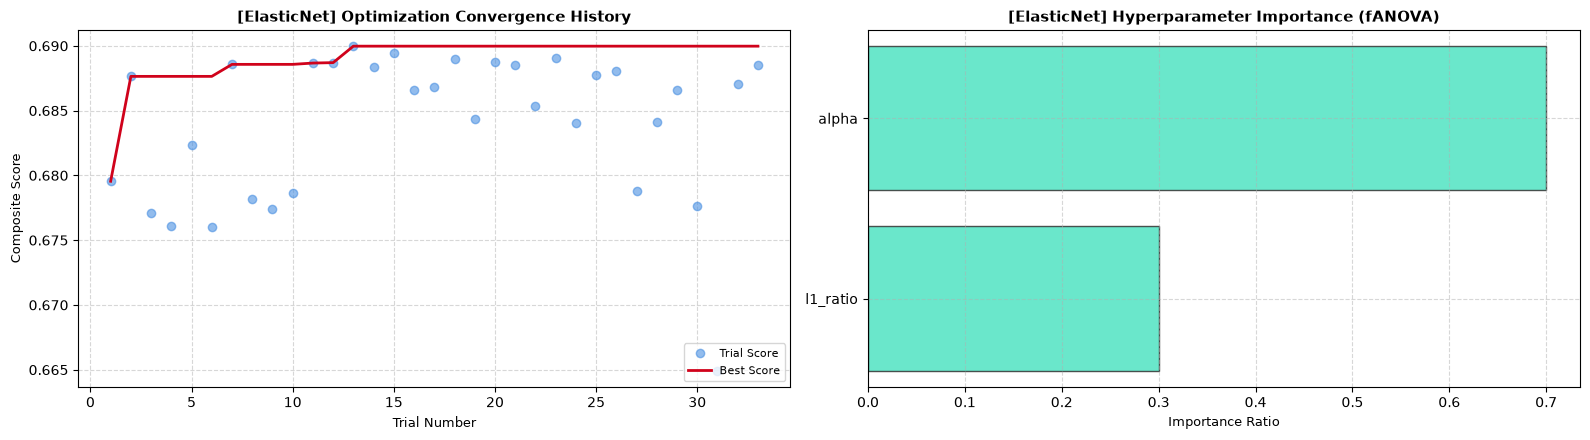

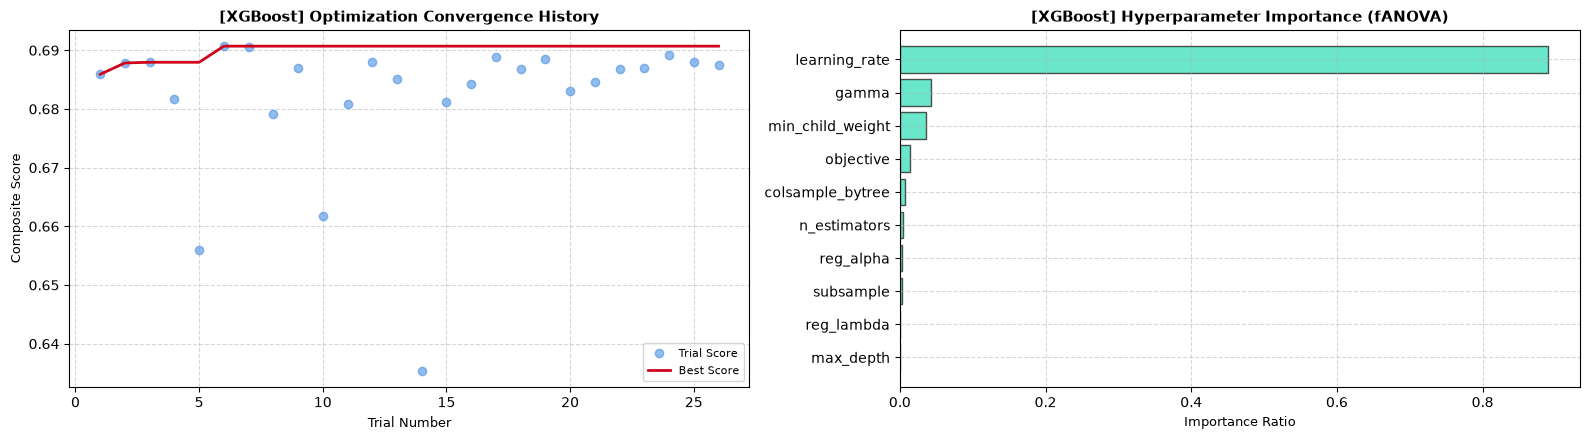

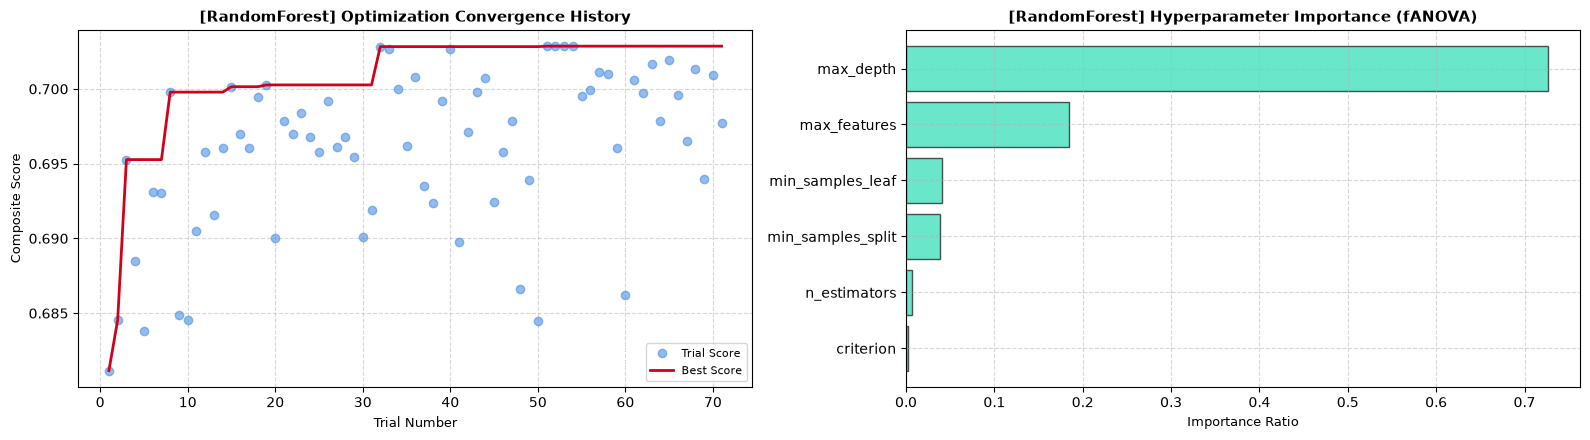

In [7]:
# ==============================================================================
# [셀 2] 3대 단일 회귀 모델군 대상 Walk-Forward CV 자율 HPO 최적화 (SingleModelOptimizer)
# ==============================================================================
import matplotlib.pyplot as plt
from src.model.optimization.search_space import get_search_spaces, audit_search_space_boundaries
from src.model.optimization.single_model_optimizer import SingleModelOptimizer
from src.model.visualization.optimizer_visualizer import OptimizerVisualizer

# ------------------------------------------------------------------------------
# Step 1. 표준 탐색 공간 로드 (필요 시 특정 파라미터 범위 Override 가능)
# ------------------------------------------------------------------------------
search_spaces = get_search_spaces()
search_spaces["RandomForest"]["min_samples_leaf"]["high"] = 15

# ------------------------------------------------------------------------------
# Step 2. 3대 단일 모델 순차 HPO 실행 및 80% Full Refit
# [설계 의도] Step 5에서 시각화 아티팩트와 함께 단일 MLflow Run으로 통합 로깅하기 위해 tracker=None 전달
# ------------------------------------------------------------------------------
single_model_optimizer = SingleModelOptimizer(
    splitter=walk_forward_splitter,
    tracker=None,
    patience=20,
    max_trials=80
)
optimization_registry = single_model_optimizer.optimize_all(
    X_train=X_train,
    y_train=y_train,
    search_spaces=search_spaces
)

# ------------------------------------------------------------------------------
# Step 3. Optuna HPO 정산 대시보드 사출
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print(" 📊 [Stage 2 Time-Series Walk-Forward HPO Optimization Summary Dashboard]")
print("=" * 122)
display(optimization_registry.summary_dataframe)

# ------------------------------------------------------------------------------
# Step 4. Search Space 경계 도달 파라미터 단일 통합 감사표 사출 (조건부)
# ------------------------------------------------------------------------------
boundary_audit_dataframe = audit_search_space_boundaries(optimization_registry.hpo_results)
if not boundary_audit_dataframe.empty:
    print("\n" + "-" * 122)
    print(" ⚠️ [Search Space Boundary Adjustment Required Table]")
    print("-" * 122)
    display(boundary_audit_dataframe)

# ------------------------------------------------------------------------------
# Step 5. HPO 최적화 수렴 궤적 및 파라미터 중요도 시각화 사출 및 MLflow 로깅
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print(" 📈 [Stage 2 HPO Convergence History & Parameter Importance Visualization]")
print("=" * 122)

for model_name, result_dto in optimization_registry.hpo_results.items():
    convergence_figure = OptimizerVisualizer.plot_convergence(
        study=result_dto.study,
        model_name=model_name
    )
    # [설계 의도] 수치 지표, 파라미터, 시각화 플롯 아티팩트를 단일 Active Run으로 원자적 영속화
    tracker.log_hpo_result(
        model_name=model_name,
        result_dto=result_dto,
        fig=convergence_figure
    )
    plt.show()

In [10]:
# ==============================================================================
# [셀 3] Walk-Forward CV 기반 Default vs Tuned 비교 평가 및 최종 1위 Champion 모델 확정
# ==============================================================================
from src.model.evaluation.single_model_evaluator import SingleModelEvaluator

# ------------------------------------------------------------------------------
# Step 1. 3대 모델 Holdout Test 실전 평가 집행
# ------------------------------------------------------------------------------
single_model_evaluator = SingleModelEvaluator(tracker=tracker)
comparison_df = single_model_evaluator.evaluate(
    optimization_registry=optimization_registry,
    X_test=X_test,
    y_test=y_test
)

# ------------------------------------------------------------------------------
# Step 2. 다차원 평가 기준 기반 최종 1위 Champion 단일 모델 발탁
# ------------------------------------------------------------------------------
champion = single_model_evaluator.get_best_model(criterion="composite")

# 후속 셀([셀 4], [셀 5]) 연동을 위한 Champion 변수 바인딩
champion_model_name = champion.name
champion_model = champion.model
champion_cv_mda = champion.cv_mda
champion_cv_rmse = champion.cv_rmse
champion_composite_score = champion.composite_score
champion_test_mda = champion.test_mda
champion_test_rmse = champion.test_rmse
champion_test_mae = champion.test_mae

# ------------------------------------------------------------------------------
# Step 3. 포트폴리오 맞춤형 비교 리포트 및 Champion 발탁 대시보드 사출
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print(f" 🏆 [Champion Model Final Selection] 최종 1위 단일 챔피언 모델: '{champion.name}'")
print(f" 📌 Walk-Forward CV 성능: MDA {champion.cv_mda * 100.0:.2f}% | RMSE {champion.cv_rmse:.6f} | Composite {champion.composite_score:.4f}")
print(f" 🎯 Out-of-Sample Test 성능: MDA {champion.test_mda * 100.0:.2f}% | RMSE {champion.test_rmse:.6f} | MAE {champion.test_mae:.6f}")
print("=" * 122)

display(single_model_evaluator.display_dataframe)

 🚀 [Default vs Tuned Model Performance Comparison Launch]
 🎯 Out-of-Sample Holdout Partition: Test Set (497, 23) (Pure Unseen Future)

 🏆 [Champion Model Final Selection] 최종 1위 단일 챔피언 모델: 'RandomForest'
 📌 Walk-Forward CV 성능: MDA 76.65% | RMSE 0.398213 | Composite 0.7029
 🎯 Out-of-Sample Test 성능: MDA 69.15% | RMSE 0.608600 | MAE 0.369329


,Default CV MDA,Tuned CV MDA,CV MDA 개선폭 (Δ),Default CV RMSE,Tuned CV RMSE,CV RMSE 개선폭 (Δ),CV 복합 점수 (Composite),Tuned Test MDA,Tuned Test RMSE,Tuned Test MAE,추론 속도 (Latency)
알고리즘 (Algorithm),,,,,,,,,,,
ElasticNet,75.03%,75.74%,+0.71%p,0.412263,0.421656,+0.009393,0.6900,69.15%,0.570007,0.383463,0.97 ms
XGBoost,74.52%,75.43%,+0.91%p,0.396628,0.398047,+0.001418,0.6907,69.35%,0.586397,0.369170,1.23 ms
RandomForest,74.92%,76.65%,+1.73%p,0.408621,0.398213,-0.010407,0.7029,69.15%,0.608600,0.369329,28.05 ms


 🚀 [Explainable AI (SHAP) Analysis Launch] Target Champion Model: 'RandomForest'
 📌 Target Feature Matrix Shape: (1987, 23) (Full Train Partition)


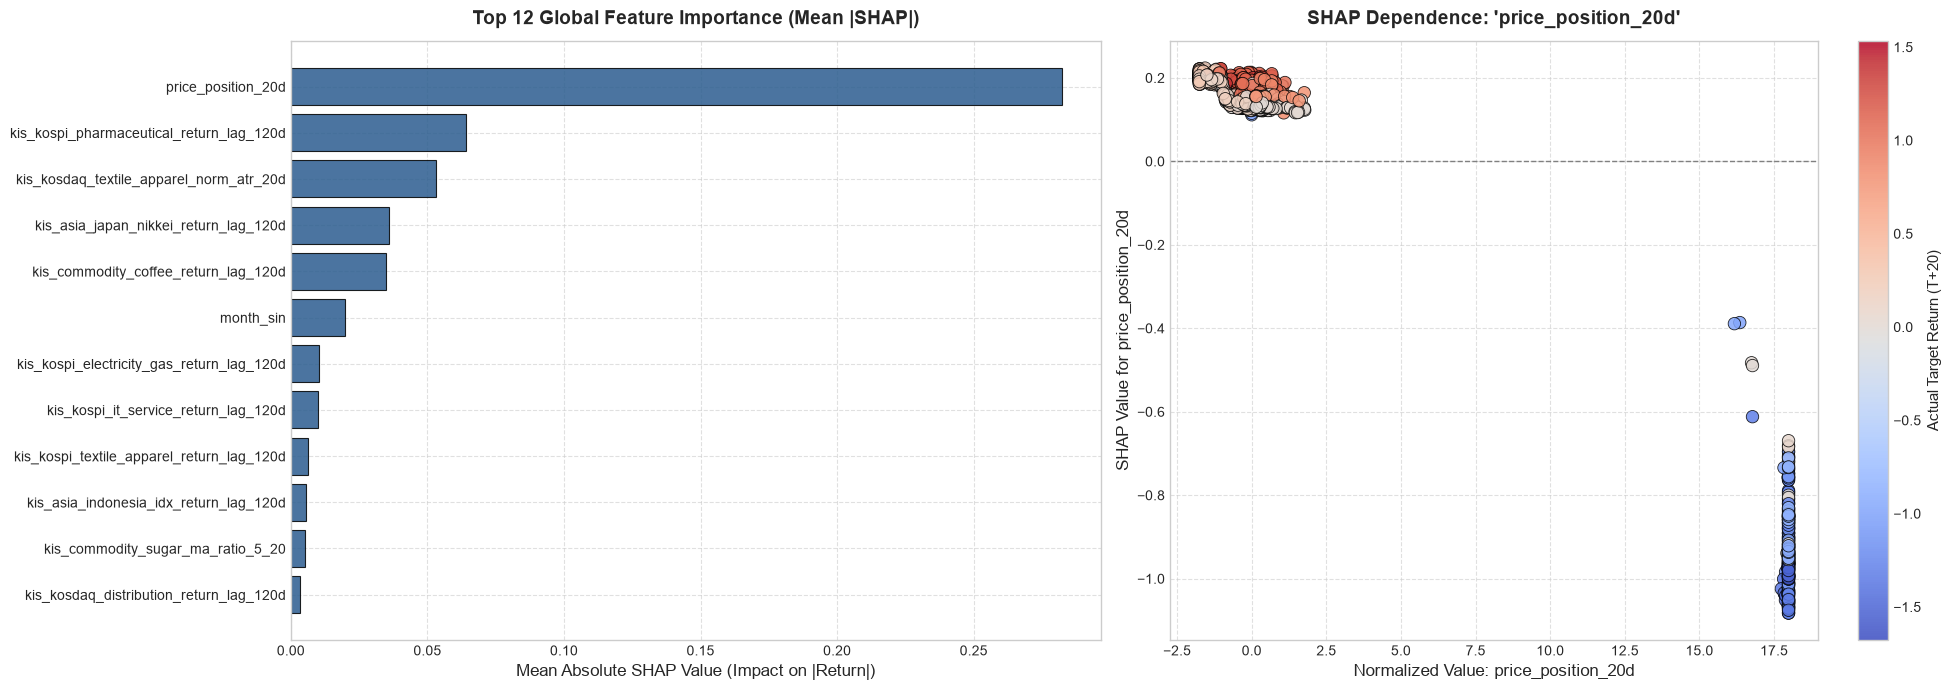

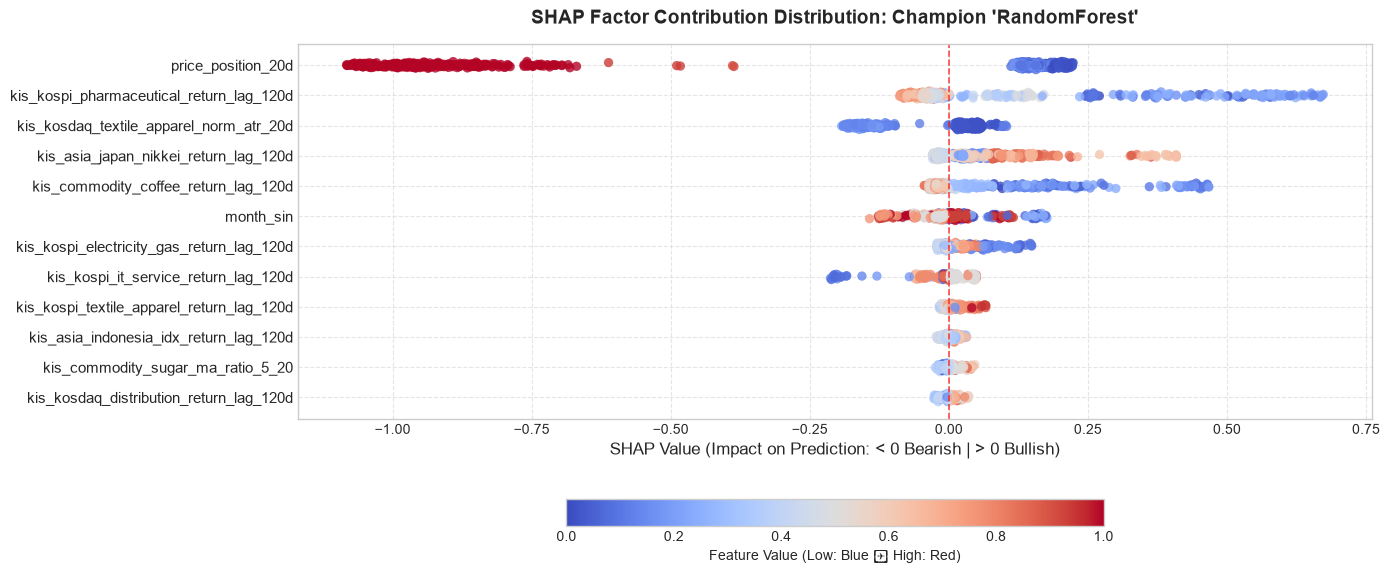


 📊 [SHAP Factor Contribution Ranking Dashboard] Top Driver Factor: 'price_position_20d'


,피처 명칭 (Feature Name),평균 절대 SHAP (Mean |SHAP|),기여도 비중 (Importance %),주요 기여 방향성 (Market Bias)
Rank,,,,
1,price_position_20d,0.282455,51.22%,하락 압력 (Bearish)
2,kis_kospi_pharmaceutical_return_lag_120d,0.064229,11.65%,하락 압력 (Bearish)
3,kis_kosdaq_textile_apparel_norm_atr_20d,0.053288,9.66%,하락 압력 (Bearish)
4,kis_asia_japan_nikkei_return_lag_120d,0.036004,6.53%,상승 견인 (Bullish)
5,kis_commodity_coffee_return_lag_120d,0.034729,6.30%,하락 압력 (Bearish)
6,month_sin,0.019721,3.58%,하락 압력 (Bearish)
7,kis_kospi_electricity_gas_return_lag_120d,0.010364,1.88%,하락 압력 (Bearish)
8,kis_kospi_it_service_return_lag_120d,0.009766,1.77%,상승 견인 (Bullish)
9,kis_kospi_textile_apparel_return_lag_120d,0.006386,1.16%,상승 견인 (Bullish)


In [11]:
# ==============================================================================
# [셀 4] SHAP 기반 XAI 거시 금융 팩터 해석 (Explainable AI)
# ==============================================================================
import matplotlib.pyplot as plt
from src.model.evaluation.shap_explainer import ShapExplainer
from src.model.visualization.shap_visualizer import ShapVisualizer

print("=" * 122)
print(f" 🚀 [Explainable AI (SHAP) Analysis Launch] Target Champion Model: '{champion_model_name}'")
print(f" 📌 Target Feature Matrix Shape: {X_train.shape} (Full Train Partition)")
print("=" * 122)

# ------------------------------------------------------------------------------
# Step 1 & 2. SHAP 값 다형성 산출 및 정량적 팩터 기여도 정산 (단 2줄)
# ------------------------------------------------------------------------------
shap_explainer = ShapExplainer()
shap_result = shap_explainer.explain(model=champion_model, X_train=X_train)

# ------------------------------------------------------------------------------
# Step 3. 포트폴리오 맞춤형 SHAP XAI 종합 시각화 리포트 사출 (단 4줄)
# ------------------------------------------------------------------------------
fig_importance = ShapVisualizer.plot_importance_and_dependence(X_train=X_train, y_train=y_train, shap_result=shap_result)
plt.show()

fig_distribution = ShapVisualizer.plot_factor_distribution(X_train=X_train, shap_result=shap_result, champion_model_name=champion_model_name)
plt.show()

# ------------------------------------------------------------------------------
# Step 4. XAI 팩터 기여도 정산 대시보드 표 사출 및 MLflow 일괄 영속화
# ------------------------------------------------------------------------------
print("\n" + "=" * 122)
print(f" 📊 [SHAP Factor Contribution Ranking Dashboard] Top Driver Factor: '{shap_result.top_feature_name}'")
print("=" * 122)
display(shap_result.display_dataframe.head(10))

tracker.log_xai_reports(
    champion_model_name=champion_model_name,
    shap_ranking_dataframe=shap_result.ranking_dataframe,
    fig_importance=fig_importance,
    fig_distribution=fig_distribution,
    top_driver_feature=shap_result.top_feature_name
)

In [19]:
# ==============================================================================
# [셀 5] 챔피언 모델 아티팩트(champion_model.pkl) 직렬화 저장 및 배포 검증
# ==============================================================================
from src.model.deployment.single_model_deployer import SingleModelDeployer

print("=" * 122)
print(f" 🚀 [Champion Model Deployment Pipeline Launch] Target Champion: '{champion_model_name}'")
print("=" * 122)

deployer = SingleModelDeployer()

# ------------------------------------------------------------------------------
# Step 1. 챔피언 모델 아티팩트 직렬화 저장 (Save)
# ------------------------------------------------------------------------------
artifact_path = deployer.save(model=champion_model, artifact_path="champion_model.pkl")

# ------------------------------------------------------------------------------
# Step 2. 저장된 아티팩트 복원 무결성 및 추론 레이턴시 검증 (Verify)
# ------------------------------------------------------------------------------
verification_result = deployer.verify(
    champion_dto=champion,
    X_test=X_test,
    y_test=y_test,
    artifact_path=artifact_path
)

# ------------------------------------------------------------------------------
# Step 3. 최종 모델 배포 사출서 생성 및 대시보드 출력 (Summarize)
# ------------------------------------------------------------------------------
deployment_summary_dataframe = deployer.summarize(
    champion_dto=champion,
    verification_result=verification_result
)

print("\n" + "=" * 122)
print(" 🎯 [AssetMind Champion Model Final Deployment Specification]")
print("=" * 122)
display(deployment_summary_dataframe)

# ------------------------------------------------------------------------------
# Step 4. MLflow Model Registry 정식 승격 및 아티팩트 영속화
# ------------------------------------------------------------------------------
tracker.register_champion_model(
    champion_model_name=champion_model_name,
    artifact_path=artifact_path,
    deployment_summary_dataframe=deployment_summary_dataframe,
    single_sample_latency_ms=verification_result.single_sample_latency_ms
)

 🚀 [Champion Model Deployment Pipeline Launch] Target Champion: 'RandomForest'
💾 [Artifact Saved] 'champion_model.pkl' (크기: 844.19 KB)

 🎯 [AssetMind Champion Model Final Deployment Specification]


,세부 내용 (Value)
항목 (Field),
챔피언 모델 알고리즘 (Algorithm),RandomForest
모델 아티팩트 경로 (Artifact Path),champion_model.pkl
아티팩트 파일 크기 (File Size),844.19 KB
최종 투입 피처 수 (Feature Dimension),23 Features
최적 하이퍼파라미터 (Best Parameters),"criterion=squared_error, n_estimators=225, max_depth=6, min_samples_split=14, min_samples_leaf=13, max_features=0.9144, random_state=42"
Walk-Forward CV 평균 적중률 (CV MDA),76.65%
Walk-Forward CV 평균 제곱근 오차 (CV RMSE),0.398213
Walk-Forward CV 복합 최적화 점수 (Composite),0.7029
테스트 세트 방향성 정확도 (Test MDA),69.15%


🎯 [MLflow Model Registry] 'Champion_AssetMind_Regressor' (Version: 7) 정식 승격 완료
